In [122]:
'''
Basics of Python
- Lists, arrays, matrices, dataframes
- Operations on lists, numpy arrays, matrices dataframes e.g. matrix multiplication,
transpose, inverse, etc
- Pandas commands
'''

'\nBasics of Python\n- Lists, arrays, matrices, dataframes\n- Operations on lists, numpy arrays, matrices dataframes e.g. matrix multiplication,\ntranspose, inverse, etc\n- Pandas commands\n'

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [124]:
l = [1,2,3,4,5]

#access the first two elements from the end of the list
l[:-3:1]

[1, 2]

In [125]:
ll = np.array(l)
#what is the shape of this array
ll.shape
#this shows that l is a one dimensional array with 5 elements which can be said by (5,)
#if it was a 2d array with 5 rows and 1 column, it would be (5,1)

(5,)

In [126]:
#cosine similarity
from numpy import linalg, dot
from numpy.linalg import norm
A = np.array([1, 2, 3])
B = np.array([4, 5, 6])

print(A@B/(norm(A)*norm(B)))
print(dot(A, B)/(norm(A)*norm(B)))
print(np.dot(A, B)/(np.linalg.norm(A)*np.linalg.norm(B)))

0.9746318461970762
0.9746318461970762
0.9746318461970762


In [127]:
print(A)
print(A.T)
print(A.shape)
print(A.T.shape)

[1 2 3]
[1 2 3]
(3,)
(3,)


In [128]:
C = np.array([[1,2,3,4],[4,5,6,4],[7,8,9,4]])
print(C)
print()
print(C.T)
print()
print(C.shape)
print()
print(C.T.shape)
print()
print(np.linalg.inv(C))


[[1 2 3 4]
 [4 5 6 4]
 [7 8 9 4]]

[[1 4 7]
 [2 5 8]
 [3 6 9]
 [4 4 4]]

(3, 4)

(4, 3)



LinAlgError: Last 2 dimensions of the array must be square

In [129]:
#pandas commands
import pandas as pd 
dataframe = pd.read_csv("https://raw.githubusercontent.com/a-nagar/cs4372/refs/heads/main/data/model-results.csv", header=None)
print(dataframe)
#How can I specify that the csv file I am reading into a Pandas Dataframe has no header? I put header=None in the read_csv function.

          0          1
0    actual  predicted
1         1          1
2         1          1
3         1          1
4         1          1
..      ...        ...
356       0          0
357       0          0
358       0          0
359       0          0
360       0          0

[361 rows x 2 columns]


In [131]:
#if there are null values in the dataframe, how can I remove them without creating a new dataframe?
dataframe.dropna(inplace=True)
#dataframe.dropna() #this creates a new dataframe without null values

#how do I specify that I want to average null values in a dataframe column with the mean of that column?
# First, convert columns to numeric, skipping the header row
dataframe.iloc[1:] = dataframe.iloc[1:].apply(pd.to_numeric, errors='coerce')
dataframe.fillna(dataframe.mean(numeric_only=True), inplace=True)
#dataframe.fillna(dataframe.mean(numeric_only=True)) #this creates a new dataframe with null values replaced

In [132]:
#sklearn titanic dataset
from sklearn.datasets import fetch_openml
titanic = fetch_openml('titanic', version=1, as_frame=True)
titanicframe = titanic.frame
print(titanicframe.head())


   pclass survived                                             name     sex  \
0       1        1                    Allen, Miss. Elisabeth Walton  female   
1       1        1                   Allison, Master. Hudson Trevor    male   
2       1        0                     Allison, Miss. Helen Loraine  female   
3       1        0             Allison, Mr. Hudson Joshua Creighton    male   
4       1        0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.0000      0      0   24160  211.3375       B5        S    2    NaN   
1   0.9167      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.0000      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  
0                     St Louis,

In [133]:
#the groupby command in pandas does what?
#it groups the dataframe by the specified column(s) and allows you to perform aggregate functions on the grouped data
#aggregate functions include sum, mean, count, etc. and aggregate functions can be applied to multiple columns at once
#aggregate stands for a summary statistic that represents a group of values
#in this case we can group by
titanicframe.groupby('pclass').mean(numeric_only=True)
#this groups the dataframe by the pclass column and then calculates the mean of all numeric columns for each pclass group
#the numeric_only=True argument is used to ignore non-numeric columns when calculating the mean

#sibsp column in the titanic dataset stands for what?
#it stands for the number of siblings/spouses aboard the titanic

#while parch column in the titanic dataset stands for what?
#it stands for the number of parents/children aboard the titanic

,age,sibsp,parch,fare,body
pclass,,,,,
1,39.159918,0.436533,0.365325,87.508992,162.828571
2,29.506705,0.393502,0.368231,21.179196,167.387097
3,24.816367,0.568406,0.400564,13.302889,155.818182


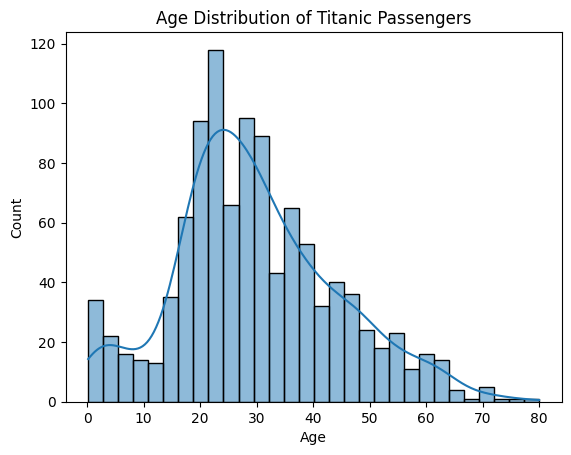

In [134]:
titanicframe['family_size'] = titanicframe['sibsp'] + titanicframe['parch'] + 1
#this creates a new column in the titanic dataframe called family_size which is the sum of the sibsp and parch columns plus 1 for the person themselves

#how do I create a histogram of the age column in the titanic dataframe?
sns.histplot(data=titanicframe, x='age', bins=30, kde=True)
plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

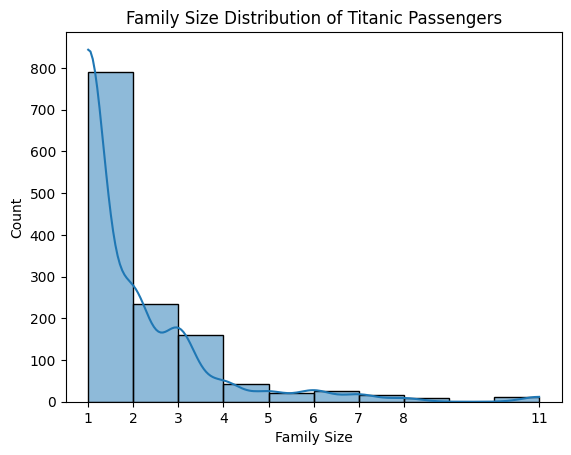

In [135]:
#hist of family size
sns.histplot(data=titanicframe, x='family_size', bins=10, kde=True)
plt.title('Family Size Distribution of Titanic Passengers')
plt.xlabel('Family Size')
plt.ylabel('Count')
#show all numbers in the x axis
plt.xticks(titanicframe['family_size'].unique())
plt.show()


In [136]:
#print family size where it is greater than 8
titanicframe[titanicframe['family_size'] > 8][['name', 'family_size', 'sibsp', 'parch']]
#we use double brackets to select multiple columns from the dataframe
#if we used single brackets, it would return a series instead of a dataframe

,name,family_size,sibsp,parch
1170,"Sage, Master. Thomas Henry",11,8,2
1171,"Sage, Master. William Henry",11,8,2
1172,"Sage, Miss. Ada",11,8,2
1173,"Sage, Miss. Constance Gladys",11,8,2
1174,"Sage, Miss. Dorothy Edith 'Dolly'",11,8,2
1175,"Sage, Miss. Stella Anna",11,8,2
1176,"Sage, Mr. Douglas Bullen",11,8,2
1177,"Sage, Mr. Frederick",11,8,2
1178,"Sage, Mr. George John Jr",11,8,2
1179,"Sage, Mr. John George",11,1,9


In [137]:
titanicframe[titanicframe['family_size'] > 5]
#we put titanic frame inside of titanicframe[...] to filter the dataframe based on a condition
#or titanicframe.loc[titanicframe['family_size'] > 5]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,family_size
111,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S,10,NaN,"Winnipeg, MB",6
112,1,1,"Fortune, Miss. Ethel Flora",female,28.0,3,2,19950,263.0000,C23 C25 C27,S,10,NaN,"Winnipeg, MB",6
113,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S,10,NaN,"Winnipeg, MB",6
114,1,0,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S,NaN,NaN,"Winnipeg, MB",6
115,1,0,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S,NaN,NaN,"Winnipeg, MB",6
116,1,1,"Fortune, Mrs. Mark (Mary McDougald)",female,60.0,1,4,19950,263.0000,C23 C25 C27,S,10,NaN,"Winnipeg, MB",6
550,2,1,"Richards, Mrs. Sidney (Emily Hocking)",female,24.0,2,3,29106,18.7500,NaN,S,4,NaN,"Cornwall / Akron, OH",6
622,3,0,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,347082,31.2750,NaN,S,NaN,NaN,"Sweden Winnipeg, MN",7
623,3,0,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.2750,NaN,S,NaN,NaN,"Sweden Winnipeg, MN",7
624,3,0,"Andersson, Miss. Ellis Anna Maria",female,2.0,4,2,347082,31.2750,NaN,S,NaN,NaN,"Sweden Winnipeg, MN",7


In [138]:
#difference between loc and iloc in pandas
#loc is used to access rows and columns by label (name) whereas iloc is used to access rows and columns by integer position (index)
#for example, to access the first row using loc and iloc
titanicframe.loc[0]  #accesses the row with index label 0


pclass                                     1
survived                                   1
name           Allen, Miss. Elisabeth Walton
sex                                   female
age                                     29.0
sibsp                                      0
parch                                      0
ticket                                 24160
fare                                211.3375
cabin                                     B5
embarked                                   S
boat                                       2
body                                     NaN
home.dest                       St Louis, MO
family_size                                1
Name: 0, dtype: object

In [139]:
titanicframe.iloc[0] #accesses the first row

pclass                                     1
survived                                   1
name           Allen, Miss. Elisabeth Walton
sex                                   female
age                                     29.0
sibsp                                      0
parch                                      0
ticket                                 24160
fare                                211.3375
cabin                                     B5
embarked                                   S
boat                                       2
body                                     NaN
home.dest                       St Louis, MO
family_size                                1
Name: 0, dtype: object

In [140]:
#now use loc to access the first 5 rows and the age and fare columns
titanicframe.loc[0:4, ['age', 'fare']]

,age,fare
0,29.0000,211.3375
1,0.9167,151.5500
2,2.0000,151.5500
3,30.0000,151.5500
4,25.0000,151.5500


In [141]:
#now use iloc to access the first 5 rows and the age and fare columns
titanicframe.iloc[0:5, [3, 9]]

,sex,cabin
0,female,B5
1,male,C22 C26
2,female,C22 C26
3,male,C22 C26
4,female,C22 C26


In [142]:
# Convert 'survived' to int for aggregation
titanicframe.groupby('pclass').agg({
	'age': 'mean',
	'fare': 'mean',
	'family_size': 'max',
	'survived': lambda x: x.astype(int).sum()
})
#this groups the dataframe by the pclass column and then calculates the mean of the age and fare columns, the sum of the survived column, and the max of the family_size column for each

,age,fare,family_size,survived
pclass,,,,
1,39.159918,87.508992,6,200
2,29.506705,21.179196,6,119
3,24.816367,13.302889,11,181


In [143]:
#get the number of people who survived in each pclass
#survived is catagorical (0 or 1) so we need to convert it to int to get the sum
titanicframe['survived'] = titanicframe['survived'].astype(int)
titanicframe.groupby('pclass')['survived'].sum()

pclass
1    200
2    119
3    181
Name: survived, dtype: int64

In [144]:
#print the mean of the age of people who survived in each pclass and the sum of the people who survived in each pclass
#this is not a meaningful statistic but just to show how to do it
titanicframe.groupby('pclass').agg({'age': ['mean', 'sum'],'survived': 'sum'})

age             survived
             mean         sum      sum
pclass                                
1       39.159918  11121.4167      200
2       29.506705   7701.2500      119
3       24.816367  12433.0000      181

In [145]:
#create a pivot table of the titanic dataframe with pclass as the index and age, fare, family_size, and survived as the values
# the pivot table will show all values of each column
titanicframe.pivot_table(index='pclass', values=['age', 'fare', 'family_size', 'survived'],
                         aggfunc={'age': 'mean', 'fare': 'mean', 'family_size': 'max', 'survived': 'sum'})

,age,family_size,fare,survived
pclass,,,,
1,39.159918,6,87.508992,200
2,29.506705,6,21.179196,119
3,24.816367,11,13.302889,181


In [151]:
titanicframe.groupby(['sex', 'survived', 'pclass']).agg({'age': ['mean'], 'fare': ['std']})

/var/folders/mq/9_3g72h153d7dwykw58qs09h0000gn/T/ipykernel_56740/3693201508.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanicframe.groupby(['sex', 'survived', 'pclass']).agg({'age': ['mean'], 'fare': ['std']})


age       fare
                             mean        std
sex    survived pclass                      
female 0        1       35.200000  84.321398
                2       34.090909   6.208956
                3       23.418750  14.958090
       1        1       37.109375  83.130611
                2       26.711051  11.645476
                3       20.814815   5.694249
male   0        1       43.658163  62.925670
                2       33.092593  15.533788
                3       26.679598  10.786874
       1        1       36.168240  92.449397
                2       17.449274   9.401452
                3       22.436441  13.581856

In [155]:
titanicframe.groupby(['sex', 'survived', 'pclass'])[['age', 'fare']].mean()

/var/folders/mq/9_3g72h153d7dwykw58qs09h0000gn/T/ipykernel_56740/1209572012.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanicframe.groupby(['sex', 'survived', 'pclass'])[['age', 'fare']].mean()


age        fare
sex    survived pclass                       
female 0        1       35.200000  117.054180
                2       34.090909   19.125000
                3       23.418750   18.367162
       1        1       37.109375  109.137500
                2       26.711051   23.759486
                3       20.814815   12.166510
male   0        1       43.658163   68.436192
                2       33.092593   19.857334
                3       26.679598   12.134521
       1        1       36.168240   72.697546
                2       17.449274   20.183000
                3       22.436441   13.977496

In [158]:
fruits = ['apple', 'banana', 'cherry', 'kiwi', 'mango']

fruits[:-3:1]

['apple', 'banana']

In [159]:
fruits[:-3:-1]

['mango', 'kiwi']

In [160]:
fruits[:-2:-1]

['mango']

In [161]:
fruits[-2:0:-1]

['kiwi', 'cherry', 'banana']

In [170]:
d = np.linspace(0,10, 5, endpoint=False)
d

array([0., 2., 4., 6., 8.])

In [175]:
#matrices and matrix operations
A = np.array([[1,2,3,4],[4,5,6,4],[7,8,9,4]])
B = np.array([[9,8,7],[6,5,4],[3,2,1]])
A.ndim


2